# Check your calibration

Quick sanity check that your PONI + mask load correctly and look right. Run this any time you set up a new beamtime or generate a new calibration with `pyFAI-calib2`. See [`docs/calibration.md`](../docs/calibration.md) for how to produce these files in the first place.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

from giwaxs_analysis import calibration, io

## 1. Point at your files

Defaults below point at the sample AgBh calibration in `data/`. Swap them for your own when running on real data.

In [2]:
PONI_PATH = '../data/calibrant_AgBh.poni'
MASK_PATH = '../data/mask.edf'
CALIBRANT_PATH = '../data/calibrant_AgBh.edf'

## 2. Load and summarise

`load_calibration` packs the geometry + mask into a single `Calibration` object you can pass around. `summarise()` prints a one-liner; check it to make sure the distance, beam centre and wavelength look right for your beamtime.

**In particular, check the beam energy** (`E=` in the output). The energy is baked into the `.poni` file at calibration time and is easy to get wrong if you're reusing an old `.poni` for a new beamtime. Cross-check against your beamtime logbook. This example uses a 10 keV image of AgBh at the Advanced Light Source taken on a Pilatus 2M dtector.

In [3]:
calib = calibration.load_calibration(PONI_PATH, MASK_PATH)
print(calibration.summarise(calib))

Pilatus2M  dist=275.7 mm  beam=(209.9, 35.8) mm  λ=1.2398 Å  E=10.000 keV  masked=8.0%


## 3. Visualise the mask

Sanity-check that the mask covers what you expect: detector module gaps, the beamstop shadow, and any dead pixels. **Dark = masked** (pyFAI will ignore these); light = valid.

If the mask looks inverted (most of the detector dark instead of light), the convention might be flipped - re-export it from `pyFAI-calib2` or invert it manually before saving. Manual inversion can be done with the `pyFAI-calib2` GUI. 

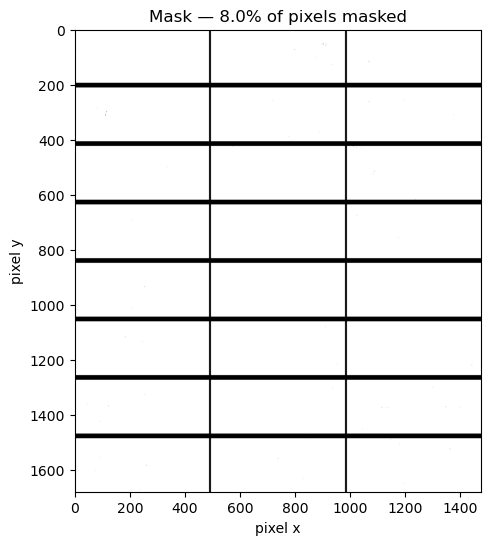

In [6]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(calib.mask, cmap='gray_r')
ax.set_title(f'Mask — {100 * calib.mask.sum() / calib.mask.size:.1f}% of pixels masked')
ax.set_xlabel('pixel x')
ax.set_ylabel('pixel y')
plt.show()

## 4. Visualise the calibrant frame

The calibrant image (AgBh here) should show concentric rings centred on the beam. If the rings look off-centre or elliptical, your geometry is probably wrong — go back to `pyFAI-calib2` and refit.

Plotted on a log scale so the weaker outer rings are visible alongside the bright inner ones. Masked pixels are shown as transparent.

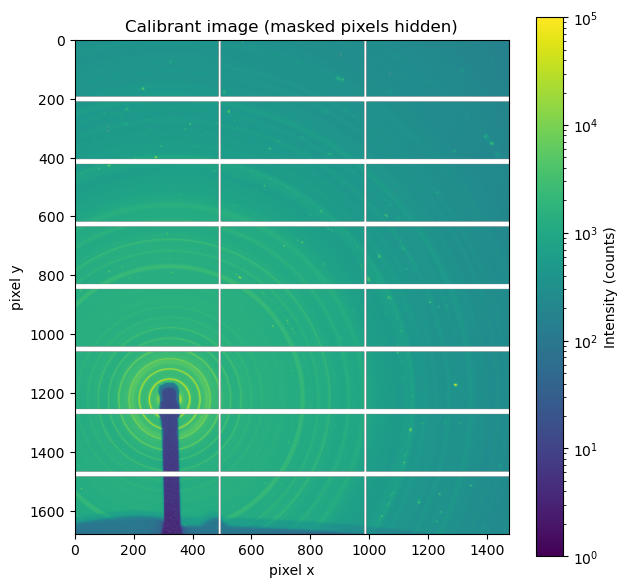

In [ ]:
# Intensity range for the colour scale. LogNorm requires vmin > 0.
# Raise VMIN to suppress noise; lower VMAX to make weak outer rings
# more visible (saturating the brightest pixels).
# Rough guide:
#   - long exposure (~30 s):  VMAX ~ 10000-100000
#   - short exposure (~3 s):  VMAX ~ 500-1000
VMIN = 1
VMAX = 100000

frame = io.load_frame(CALIBRANT_PATH).astype(float)
frame_masked = np.where(calib.mask, np.nan, frame)

fig, ax = plt.subplots(figsize=(7, 7))
im = ax.imshow(
    frame_masked,
    norm=LogNorm(vmin=VMIN, vmax=VMAX),
    cmap='viridis',
)
ax.set_title('Calibrant image (masked pixels hidden)')
ax.set_xlabel('pixel x')
ax.set_ylabel('pixel y')
plt.colorbar(im, ax=ax, label='Intensity (counts)')
plt.show()